PROJECT TITLE: RETAIL CUSTOMER SEGMENTATION

In [1]:
# 1. import the necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Data Preparation and Exploratory Data Analysis

In [2]:
# 2. Load dataset
df = pd.read_csv('Retail_pos_basket_data.csv')
df.head()

,order_id,user_id,order_date,time,order_hour_of_day,product_name,quantity,price,category,product_id
0,1000,341,04/09/2024,15:43:00,15,Wheat Flour,1,333.44,Grains & Staples,457
1,1000,341,04/09/2024,15:43:00,15,Dishwashing Liquid,2,405.92,Household,745
2,1000,341,04/09/2024,15:43:00,15,Pastry,2,114.15,Bakery,849
3,1000,341,04/09/2024,15:43:00,15,Marker,2,171.33,Stationery,599
4,1001,324,07/03/2024,8:45:00,8,Saree,2,41.16,Clothing,329


In [3]:
# 3. preliminary analysis to understand the structure and types of data columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           10000 non-null  int64  
 1   user_id            10000 non-null  int64  
 2   order_date         10000 non-null  object 
 3   time               10000 non-null  object 
 4   order_hour_of_day  10000 non-null  int64  
 5   product_name       10000 non-null  object 
 6   quantity           10000 non-null  int64  
 7   price              10000 non-null  float64
 8   category           10000 non-null  object 
 9   product_id         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB


In [4]:
df.shape

(10000, 10)

In [5]:
# Summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,10000.0,1996.630700,572.906224,1000.00,1506.0000,1996.500,2492.2500,2990.00
user_id,10000.0,248.256900,145.251605,1.00,119.0000,252.000,373.0000,500.00
order_hour_of_day,10000.0,13.808800,4.928354,6.00,9.0000,14.000,18.0000,22.00
quantity,10000.0,2.009400,0.820597,1.00,1.0000,2.000,3.0000,3.00
price,10000.0,255.973973,141.302119,10.09,132.9575,257.195,377.7725,499.96
product_id,10000.0,545.721800,260.980239,100.00,318.7500,548.000,771.0000,999.00


In [6]:
# Summary statistics for categorical variables
df.describe(include='object').T

,count,unique,top,freq
order_date,10000,363,25/09/2024,67
time,10000,896,16:00:00,43
product_name,10000,68,Chips,167
category,10000,17,Grains & Staples,1180


In [7]:
# 4. Handling missing values
df.isna().sum()

order_id             0
user_id              0
order_date           0
time                 0
order_hour_of_day    0
product_name         0
quantity             0
price                0
category             0
product_id           0
dtype: int64

In [8]:
# Handling duplicates by finding duplicate rows (keeping all instances)
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows

,order_id,user_id,order_date,time,order_hour_of_day,product_name,quantity,price,category,product_id


Feature Engineering

In [9]:
#  5. Feature Engineering: Recency, Frequency, Monetary Features

# Recency
# Convert order_date to datetime type
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst = True)

# Find the most recent purchase date for each customer
customer_Segment_data = df.groupby('user_id')['order_date'].max().reset_index()

# Find the most recent date in the entire dataset
most_recent_date = df['order_date'].max()

# Convert most_recent_date to datetime type before subtraction
customer_Segment_data['order_date'] = pd.to_datetime(customer_Segment_data['order_date'])
most_recent_date = pd.to_datetime(most_recent_date)

# Calculate the number of days since the last purchase for each customer
customer_Segment_data['Days_Since_Last_Purchase'] = (most_recent_date - customer_Segment_data['order_date'])

# Remove the order_date column
customer_Segment_data.drop(columns=['order_date'], inplace=True)
customer_Segment_data.head()

,user_id,Days_Since_Last_Purchase
0,1,6 days
1,2,11 days
2,3,77 days
3,4,168 days
4,5,279 days


In [10]:
# Frequency
# Calculate the total number of transactions made by each customer
total_transactions = df.groupby('user_id')['order_id'].nunique().reset_index()
total_transactions.rename(columns={'order_id': 'Total_Transactions'}, inplace=True)

# Calculate the total number of products purchased by each customer
total_products_purchased = df.groupby('user_id')['quantity'].sum().reset_index()
total_products_purchased.rename(columns={'quantity': 'Total_Products_Purchased'}, inplace=True)

# Merge the new features into the customer_data dataframe
customer_Segment_data = pd.merge(customer_Segment_data, total_transactions, on='user_id')
customer_Segment_data = pd.merge(customer_Segment_data, total_products_purchased, on='user_id')

# Display the first few rows of the customer_data dataframe
customer_Segment_data.head()

,user_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased
0,1,6 days,4,24
1,2,11 days,6,57
2,3,77 days,6,73
3,4,168 days,2,17
4,5,279 days,4,38


In [11]:
# Monetary
# Calculate the total spend by each customer
df['Total_Spend'] = df['price'] * df['quantity']
total_spend = df.groupby('user_id')['Total_Spend'].sum().reset_index()

# Calculate the average transaction value for each customer
average_transaction_value = total_spend.merge(total_transactions, on='user_id')
average_transaction_value['Average_Transaction_Value'] = average_transaction_value['Total_Spend'] / average_transaction_value['Total_Transactions']

# Merge the new features into the customer_data dataframe
customer_Segment_data = pd.merge(customer_Segment_data, total_spend, on='user_id')
customer_Segment_data = pd.merge(customer_Segment_data, average_transaction_value[['user_id', 'Average_Transaction_Value']], on='user_id')

# Display the first few rows of the customer_data dataframe
customer_Segment_data.head()

,user_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,1,6 days,4,24,7073.79,1768.447500
1,2,11 days,6,57,17877.07,2979.511667
2,3,77 days,6,73,18699.99,3116.665000
3,4,168 days,2,17,4390.65,2195.325000
4,5,279 days,4,38,8997.92,2249.480000


Checking for outliers

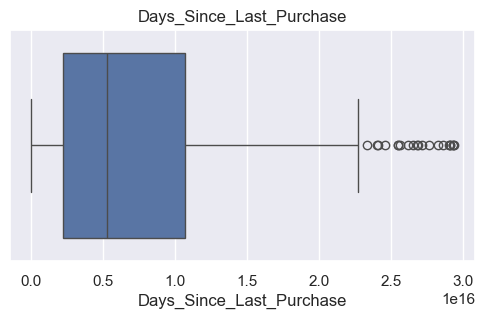

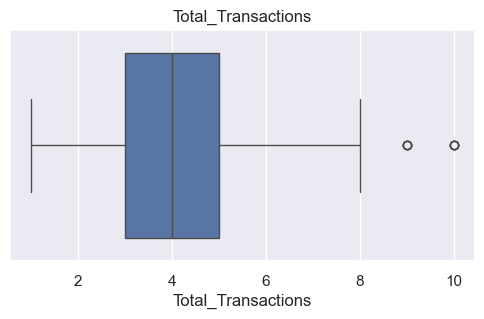

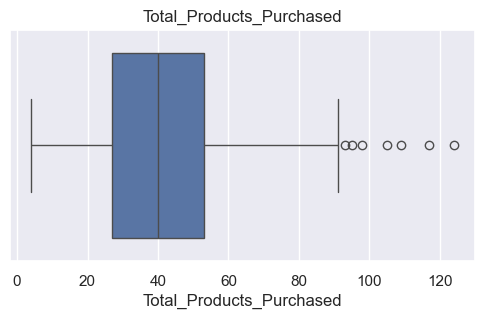

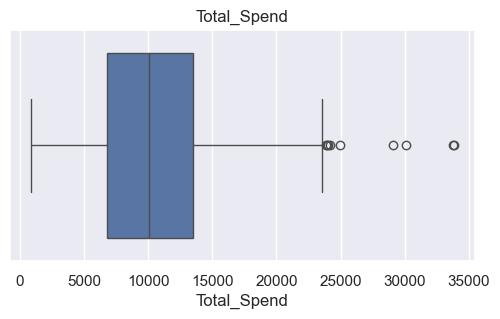

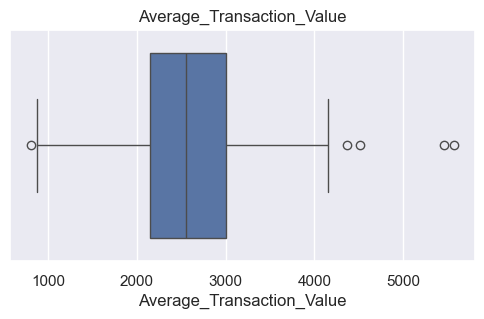

In [12]:
# 6. Check for outliers
columns = [
    'Days_Since_Last_Purchase',
    'Total_Transactions',
    'Total_Products_Purchased',
    'Total_Spend',
    'Average_Transaction_Value'
]
for col in columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=customer_Segment_data[col])
    plt.title(col)
    plt.show()

In [13]:
# Find outliers using Inter Quartile Range (IQR) and capping the extreme values
columns = [
    'Days_Since_Last_Purchase',
    'Total_Transactions',
    'Total_Products_Purchased',
    'Total_Spend',
    'Average_Transaction_Value'
]
for col in columns:
    Q1 = customer_Segment_data[col].quantile(0.25)
    Q3 = customer_Segment_data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    customer_Segment_data[col] = customer_Segment_data[col].clip(lower, upper)

Checking correlations

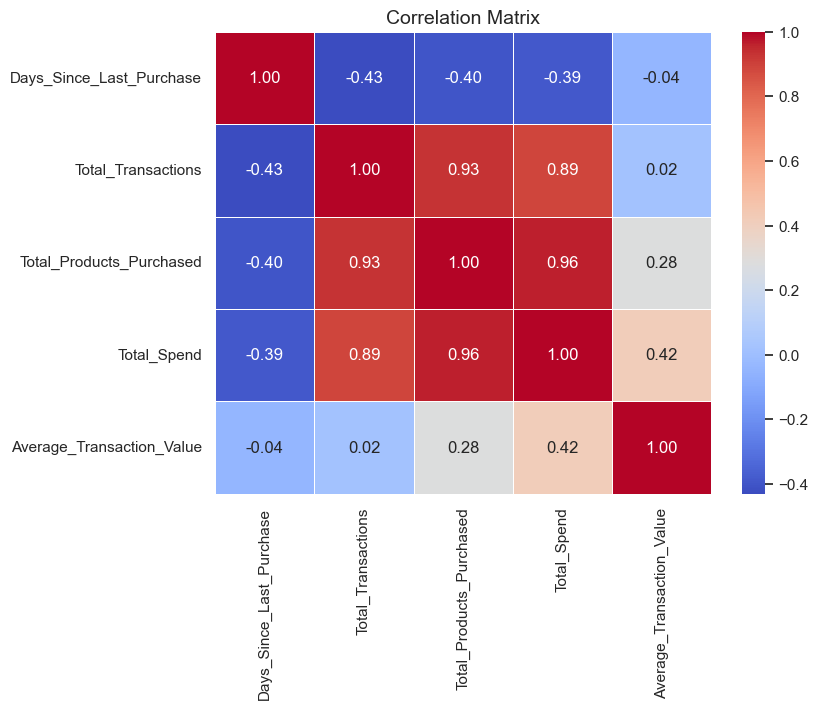

In [14]:
# Checking Correlations between features
columns = [
    'Days_Since_Last_Purchase',
    'Total_Transactions',
    'Total_Products_Purchased',
    'Total_Spend',
    'Average_Transaction_Value'
]
corr_matrix = customer_Segment_data[columns].corr()


# Reset background style
sns.set_style('whitegrid')

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.show()

Feature Scaling and Clustering 

In [16]:
# Copy the cleaned dataset
customer_data_scaled =  customer_Segment_data.copy()
customer_data_scaled.drop(columns=['user_id'], inplace = True)

#customer_Segment_data.dtypes
customer_data_scaled['Days_Since_Last_Purchase'] = (pd.to_timedelta(customer_data_scaled['Days_Since_Last_Purchase']).dt.days)
customer_data_scaled['Days_Since_Last_Purchase'].dtypes

customer_data_scaled.head()

,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value
0,6,4,24,7073.79,1768.447500
1,11,6,57,17877.07,2979.511667
2,77,6,73,18699.99,3116.665000
3,168,2,17,4390.65,2195.325000
4,269,4,38,8997.92,2249.480000


In [17]:
customer_Segment_data.dtypes

user_id                                int64
Days_Since_Last_Purchase     timedelta64[ns]
Total_Transactions                     int64
Total_Products_Purchased               int64
Total_Spend                          float64
Average_Transaction_Value            float64
dtype: object

In [18]:
customer_data_scaled.dtypes

Days_Since_Last_Purchase       int64
Total_Transactions             int64
Total_Products_Purchased       int64
Total_Spend                  float64
Average_Transaction_Value    float64
dtype: object

In [19]:
columns_to_scale = [
    'Days_Since_Last_Purchase',
    'Total_Transactions',
    'Total_Spend',
    'Average_Transaction_Value'

]
# Copy the cleaned dataset
#customer_data_scaled =  customer_Segment_data.copy()
#customer_data_scaled.drop(columns=['user_id'], inplace = True)

# Initialize the StandardScaler
scaler = StandardScaler()
customer_data_scaled = scaler.fit_transform(customer_data_scaled)
#customer_data_scaled.head() [columns_to_scale]
#(customer_data_scaled)[columns_to_scale]

The Elbow Method

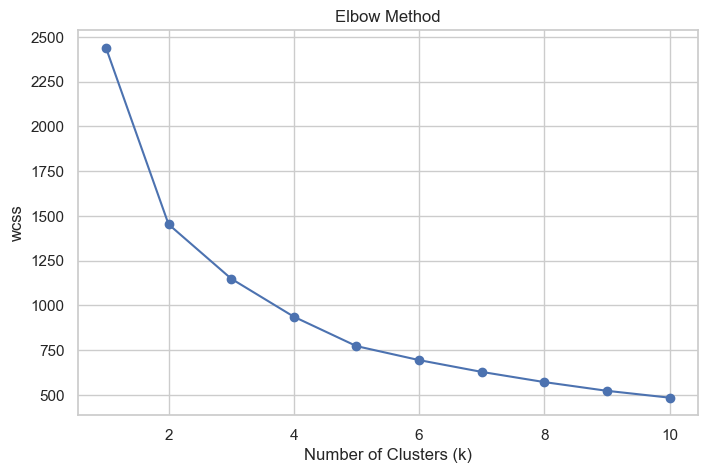

In [20]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state = 42, n_init=10)
    kmeans.fit(customer_data_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize= (8,5))
plt.plot(range(1,11), wcss, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('wcss')
plt.title('Elbow Method')
plt.show()

Evaluation using The Silhouette Score for different numbers of clusters (k)

In [21]:
# Calculating the silhouette Score 
for k in range(2,11):
    kmeans = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans.fit_predict(customer_data_scaled)
    score = silhouette_score(customer_data_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.3f}")

K = 2, Silhouette Score = 0.335
K = 3, Silhouette Score = 0.257
K = 4, Silhouette Score = 0.274
K = 5, Silhouette Score = 0.281
K = 6, Silhouette Score = 0.250
K = 7, Silhouette Score = 0.265
K = 8, Silhouette Score = 0.272
K = 9, Silhouette Score = 0.262
K = 10, Silhouette Score = 0.264


Cluster Profile

In [22]:
# converting the datatype of Days_Since_Last_Purchase
customer_Segment_data['Days_Since_Last_Purchase'] = customer_Segment_data['Days_Since_Last_Purchase'].dt.days

# creating K-Means Model
kmeans = KMeans(n_clusters=2, init = 'k-means++', random_state = 42, n_init=10)

# Fit the model and assign cluster labels
labels = kmeans.fit_predict(customer_data_scaled)
customer_Segment_data['Cluster'] = labels

customer_Segment_data.head()

,user_id,Days_Since_Last_Purchase,Total_Transactions,Total_Products_Purchased,Total_Spend,Average_Transaction_Value,Cluster
0,1,6,4,24,7073.79,1768.447500,0
1,2,11,6,57,17877.07,2979.511667,1
2,3,77,6,73,18699.99,3116.665000,1
3,4,168,2,17,4390.65,2195.325000,0
4,5,269,4,38,8997.92,2249.480000,0


In [23]:
# Check the size of each cluster
customer_Segment_data['Cluster'].value_counts()

Cluster
0    264
1    224
Name: count, dtype: int64

In [24]:
cluster_profile = customer_Segment_data.groupby('Cluster').mean(numeric_only = True)
cluster_profile.T

Cluster,0,1
user_id,253.477273,244.482143
Days_Since_Last_Purchase,107.446970,54.964286
Total_Transactions,2.787879,5.549107
Total_Products_Purchased,26.901515,57.566964
Total_Spend,6737.655000,14941.069280
Average_Transaction_Value,2467.323932,2720.400611


Cluster Size Distribution

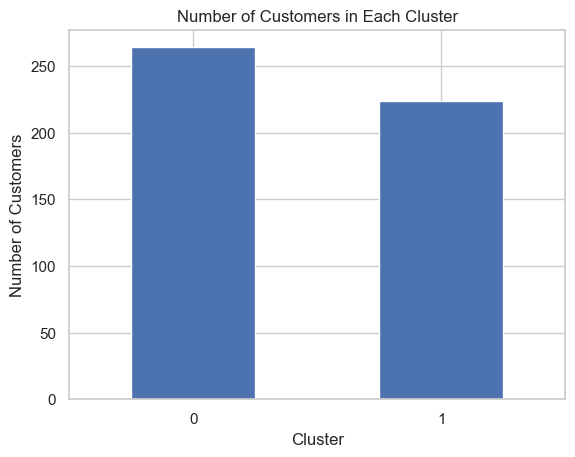

In [26]:
# Visualizing cluster with a bar chart.
customer_Segment_data['Cluster'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Customers in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.show()

Principal Component Analysis

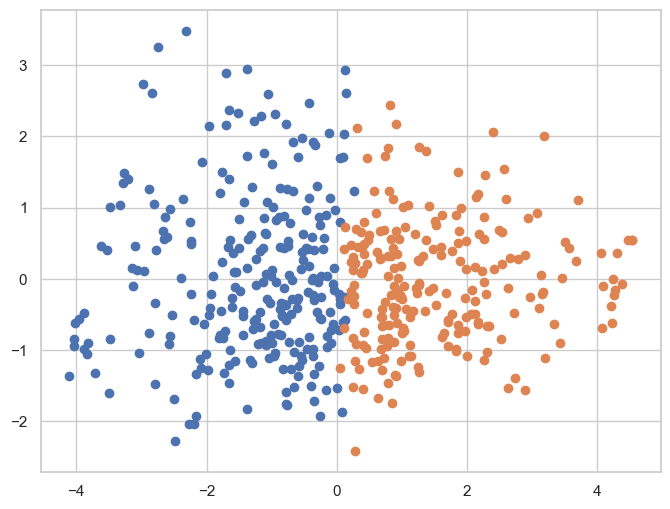

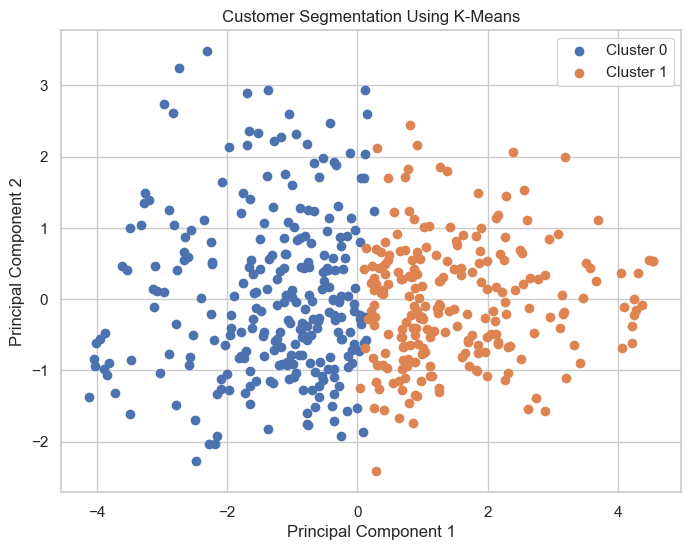

In [28]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(customer_data_scaled)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2']
)

pca_df['Cluster'] = customer_Segment_data['Cluster'].values

# Now create the visualization:
plt.figure(figsize=(8, 6))

for cluster in sorted(pca_df['Cluster'].unique()):
    cluster_data = pca_df[pca_df['Cluster'] == cluster]

    plt.scatter(
        cluster_data['PC1'],
        cluster_data['PC2'],
        label=f'Cluster {cluster}'
    )
plt.title('Customer Segmentation Using K-Means')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()